In [1]:
(* ============================================================ *)
(* S116A                                                        *)
(* ARBITRARY FINITE-STATE RESIDUAL DISCOVERY                    *)
(*                                                              *)
(* PURPOSE                                                      *)
(* ------------------------------------------------------------ *)
(* Remove the remaining "state is a known map" semantic prior.  *)
(*                                                              *)
(* Learner is NOT told that a state is:                         *)
(* - a permutation                                              *)
(* - a transformation vector                                    *)
(* - a tuple of slots                                           *)
(* - one member of a finite semantic hypothesis list            *)
(*                                                              *)
(* Learner receives only:                                       *)
(*                                                              *)
(*     Membership query:  O[sequence] -> {0,1}                  *)
(*                                                              *)
(* plus a counterexample/equivalence interface:                 *)
(*                                                              *)
(*     candidate machine -> Equivalent                          *)
(*                        OR counterexample sequence             *)
(*                                                              *)
(* Counterexample oracle NEVER exposes:                         *)
(* - true state                                                 *)
(* - true transition                                            *)
(* - intermediate trace                                         *)
(* - true state count                                           *)
(*                                                              *)
(* STATE SEMANTICS                                              *)
(* ------------------------------------------------------------ *)
(* States are induced only through residual future behavior:    *)
(*                                                              *)
(* p ~ q iff O[p . z] == O[q . z] for every future suffix z.    *)
(*                                                              *)
(* The learner uses an observation-table / distinguishing-      *)
(* suffix procedure.                                            *)
(*                                                              *)
(* TRUE MACHINE IS USED ONLY INSIDE THE ENVIRONMENT AND AFTER   *)
(* FREEZE FOR POST-HOC STRUCTURAL AUDIT.                        *)
(* ============================================================ *)


ClearAll["Global`S116A*"];
ClearAll["Global`s116A*"];


s116AResult =
Catch[

(

(* ============================================================ *)
(* 0. FAIL SAFE                                                 *)
(* ============================================================ *)

S116AFail[msg_] := (
  Print["STOP: ", msg];
  Throw[$Failed, "S116A_STOP"];
);


Print["================================================"];
Print["S116A ARBITRARY FINITE-STATE RESIDUAL DISCOVERY"];
Print["================================================"];


(* ============================================================ *)
(* 1. PUBLIC TASK INTERFACE                                     *)
(* ============================================================ *)

alphabetS116A =
  {0, 1, 2};


Print[
  "Primitive alphabet = ",
  alphabetS116A
];


Print["OUTPUT ALPHABET = {0,1}"];
Print["NO PERMUTATION PRIOR."];
Print["NO TRANSFORMATION-MAP PRIOR."];
Print["NO STATE-SEMANTIC HYPOTHESIS LIST."];
Print["NO TRUE STATE COUNT GIVEN TO LEARNER."];
Print["LEARNER SEES FINAL BINARY OUTPUT ONLY."];
Print["COUNTEREXAMPLES CONTAIN INPUT SEQUENCES ONLY."];


(* ============================================================ *)
(* 2. PROSPECTIVE HOLDOUT INPUTS                                *)
(*                                                              *)
(* Generated BEFORE learning.                                   *)
(* No membership outputs queried yet.                           *)
(* ============================================================ *)

holdoutSeedS116A =
  1161701;


holdoutDepthsS116A =
  {
    20,
    50,
    100,
    200
  };


holdoutSequencesPerDepthS116A =
  100;


prospectiveHoldoutSeqsS116A =
  BlockRandom[

    SeedRandom[
      holdoutSeedS116A
    ];


    Flatten[
      Table[

        Table[

          <|
            "Depth" -> depth,

            "Sequence" ->
              RandomChoice[
                alphabetS116A,
                depth
              ]
          |>,

          {
            holdoutSequencesPerDepthS116A
          }
        ],

        {
          depth,
          holdoutDepthsS116A
        }
      ],

      1
    ]
  ];


Print[
  "Prospective holdout sequences = ",
  Length[
    prospectiveHoldoutSeqsS116A
  ]
];


Print[
  "Holdout depths = ",
  holdoutDepthsS116A
];


Print["HOLDOUT OUTPUTS REMAIN SEALED."];


(* ============================================================ *)
(* 3. HIDDEN ARBITRARY MOORE MACHINE                            *)
(*                                                              *)
(* ENVIRONMENT ONLY.                                            *)
(*                                                              *)
(* There is deliberately no semantic interpretation of a state. *)
(* A state is simply an opaque hidden node with:                *)
(* - three outgoing transitions                                 *)
(* - one binary output                                          *)
(*                                                              *)
(* The learner never reads these tables.                        *)
(* ============================================================ *)

hiddenTransitionS116A =
  {
    {17, 11, 17},
    {6, 14, 2},
    {15, 5, 10},
    {14, 13, 13},
    {3, 5, 10},
    {8, 10, 15},
    {7, 14, 11},
    {2, 13, 5},
    {16, 2, 8},
    {4, 6, 13},
    {13, 9, 1},
    {9, 16, 10},
    {15, 16, 9},
    {13, 14, 2},
    {10, 4, 3},
    {17, 7, 11},
    {15, 12, 10}
  };


hiddenOutputS116A =
  {
    0, 1, 1, 1, 1, 0, 0, 1, 1,
    0, 1, 1, 1, 1, 0, 1, 1
  };


hiddenStartStateS116A =
  1;


S116AEnvStep[
  hiddenState_Integer,
  token_Integer
] :=
  hiddenTransitionS116A[[
    hiddenState,
    token + 1
  ]];


S116AEnvStateAfter[
  seq_List
] :=
  Fold[
    S116AEnvStep,
    hiddenStartStateS116A,
    seq
  ];


S116AEnvRawOutput[
  seq_List
] :=
  hiddenOutputS116A[[
    S116AEnvStateAfter[
      seq
    ]
  ]];


(* ============================================================ *)
(* 4. MEMBERSHIP-QUERY INTERFACE                                *)
(*                                                              *)
(* This is the only ordinary observation available to learner.  *)
(* ============================================================ *)

membershipCacheS116A =
  <||>;


membershipUniqueCountS116A =
  0;


membershipTotalCallsS116A =
  0;


S116ASeqKey[
  seq_List
] :=
  ToString[
    InputForm[
      seq
    ]
  ];


S116AMembershipY[
  seq_List
] :=
Module[
  {
    key,
    y
  },


  membershipTotalCallsS116A++;


  key =
    S116ASeqKey[
      seq
    ];


  If[
    KeyExistsQ[
      membershipCacheS116A,
      key
    ],

    Return[
      Lookup[
        membershipCacheS116A,
        key
      ]
    ]
  ];


  y =
    S116AEnvRawOutput[
      seq
    ];


  If[
    !MemberQ[
      {0, 1},
      y
    ],

    S116AFail[
      "Membership oracle returned a non-binary output."
    ]
  ];


  membershipUniqueCountS116A++;


  AssociateTo[
    membershipCacheS116A,
    key -> y
  ];


  y
];


(* ============================================================ *)
(* 5. OBSERVATION TABLE                                         *)
(*                                                              *)
(* prefixes S                                                  *)
(* suffix experiments E                                         *)
(*                                                              *)
(* row(p) = { O[p.e] : e in E }                                *)
(*                                                              *)
(* Initially E contains only empty suffix.                      *)
(* ============================================================ *)

prefixSetS116A =
  {
    {}
  };


suffixSetS116A =
  {
    {}
  };


S116ARow[
  prefix_List
] :=
  Table[

    S116AMembershipY[
      Join[
        prefix,
        suffix
      ]
    ],

    {
      suffix,
      suffixSetS116A
    }
  ];


S116ARowKey[
  row_List
] :=
  ToString[
    InputForm[
      row
    ]
  ];


S116AFrontier[] :=
  DeleteDuplicates[
    Flatten[
      Table[

        Append[
          prefix,
          token
        ],

        {
          prefix,
          prefixSetS116A
        },

        {
          token,
          alphabetS116A
        }
      ],

      1
    ]
  ];


(* ============================================================ *)
(* 6. CLOSEDNESS TEST                                           *)
(*                                                              *)
(* Every one-token extension of an access prefix must have the  *)
(* same residual row as some access prefix.                     *)
(* ============================================================ *)

S116AFindUnclosed[] :=
Module[
  {
    rowsInS,
    frontier
  },


  rowsInS =
    S116ARow /@
      prefixSetS116A;


  frontier =
    S116AFrontier[];


  SelectFirst[
    frontier,

    Function[
      candidate,

      !MemberQ[
        rowsInS,
        S116ARow[
          candidate
        ]
      ]
    ],

    Missing[
      "Closed"
    ]
  ]
];


(* ============================================================ *)
(* 7. CONSISTENCY TEST                                          *)
(*                                                              *)
(* If two prefixes currently have identical residual rows,      *)
(* applying the same primitive token must also lead to          *)
(* identical residual rows.                                    *)
(*                                                              *)
(* If not, token + old distinguishing suffix becomes a new      *)
(* future experiment.                                          *)
(* ============================================================ *)

S116AFindInconsistency[] :=
Module[
  {
    n,
    i,
    j,
    s1,
    s2,
    row1,
    row2,
    successorRow1,
    successorRow2,
    diffPosition,
    oldSuffix,
    newSuffix
  },


  n =
    Length[
      prefixSetS116A
    ];


  For[
    i = 1,
    i <= n,
    i++,


    s1 =
      prefixSetS116A[[i]];


    row1 =
      S116ARow[
        s1
      ];


    For[
      j = i + 1,
      j <= n,
      j++,


      s2 =
        prefixSetS116A[[j]];


      row2 =
        S116ARow[
          s2
        ];


      If[
        row1 === row2,


        Do[

          successorRow1 =
            S116ARow[
              Append[
                s1,
                token
              ]
            ];


          successorRow2 =
            S116ARow[
              Append[
                s2,
                token
              ]
            ];


          If[
            successorRow1 =!=
              successorRow2,


            diffPosition =
              FirstPosition[
                MapThread[
                  Unequal,
                  {
                    successorRow1,
                    successorRow2
                  }
                ],
                True
              ];


            If[
              diffPosition ===
                Missing["NotFound"],

              S116AFail[
                "Consistency mismatch found but no differing suffix position exists."
              ]
            ];


            oldSuffix =
              suffixSetS116A[[
                diffPosition[[1]]
              ]];


            newSuffix =
              Join[
                {token},
                oldSuffix
              ];


            Return[
              <|

                "Prefix1" ->
                  s1,

                "Prefix2" ->
                  s2,

                "Token" ->
                  token,

                "OldSuffix" ->
                  oldSuffix,

                "NewSuffix" ->
                  newSuffix

              |>
            ];

          ],

          {
            token,
            alphabetS116A
          }
        ];
      ];
    ];
  ];


  Missing[
    "Consistent"
  ]
];


(* ============================================================ *)
(* 8. STABILIZE OBSERVATION TABLE                               *)
(*                                                              *)
(* Repeatedly repair:                                           *)
(* - closure                                                    *)
(* - consistency                                                *)
(*                                                              *)
(* No true state information is used.                           *)
(* ============================================================ *)

tableRepairLogS116A =
  {};


S116AStabilizeTable[] :=
Module[
  {
    changed,
    unclosed,
    inconsistency
  },


  changed =
    True;


  While[
    TrueQ[
      changed
    ],


    changed =
      False;


    unclosed =
      S116AFindUnclosed[];


    If[
      !MissingQ[
        unclosed
      ],


      AppendTo[
        prefixSetS116A,
        unclosed
      ];


      prefixSetS116A =
        DeleteDuplicates[
          prefixSetS116A
        ];


      AppendTo[
        tableRepairLogS116A,

        <|
          "Type" ->
            "Closure",

          "AddedPrefix" ->
            unclosed,

          "PrefixCount" ->
            Length[
              prefixSetS116A
            ],

          "SuffixCount" ->
            Length[
              suffixSetS116A
            ]
        |>
      ];


      changed =
        True;


      Continue[];
    ];


    inconsistency =
      S116AFindInconsistency[];


    If[
      AssociationQ[
        inconsistency
      ],


      AppendTo[
        suffixSetS116A,
        inconsistency[
          "NewSuffix"
        ]
      ];


      suffixSetS116A =
        DeleteDuplicates[
          suffixSetS116A
        ];


      AppendTo[
        tableRepairLogS116A,

        <|
          "Type" ->
            "Consistency",

          "AddedSuffix" ->
            inconsistency[
              "NewSuffix"
            ],

          "PrefixCount" ->
            Length[
              prefixSetS116A
            ],

          "SuffixCount" ->
            Length[
              suffixSetS116A
            ]
        |>
      ];


      changed =
        True;


      Continue[];
    ];

  ];

];


(* ============================================================ *)
(* 9. BUILD CANDIDATE MACHINE FROM RESIDUAL ROWS                *)
(*                                                              *)
(* State = unique observation-table row.                        *)
(*                                                              *)
(* No semantic meaning or candidate mapping is attached.        *)
(* ============================================================ *)

S116ABuildHypothesis[] :=
Module[
  {
    rows,
    uniqueRows,
    rowToState,
    representativeByState,
    transitionAssoc,
    outputAssoc,
    i,
    state,
    rep,
    successorRow,
    successorState
  },


  rows =
    S116ARow /@
      prefixSetS116A;


  uniqueRows =
    DeleteDuplicates[
      rows
    ];


  rowToState =
    Association[
      Table[

        S116ARowKey[
          uniqueRows[[i]]
        ] ->
          i,

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  representativeByState =
    Association[
      Table[

        i ->

          SelectFirst[
            prefixSetS116A,

            Function[
              prefix,

              S116ARow[
                prefix
              ] ===
                uniqueRows[[i]]
            ]
          ],

        {
          i,
          Length[
            uniqueRows
          ]
        }
      ]
    ];


  transitionAssoc =
    <||>;


  outputAssoc =
    <||>;


  Do[

    state =
      i;


    rep =
      Lookup[
        representativeByState,
        state
      ];


    AssociateTo[
      outputAssoc,

      state ->
        S116AMembershipY[
          rep
        ]
    ];


    Do[

      successorRow =
        S116ARow[
          Append[
            rep,
            token
          ]
        ];


      successorState =
        Lookup[
          rowToState,

          S116ARowKey[
            successorRow
          ],

          Missing[
            "UnclosedTransition"
          ]
        ];


      If[
        MissingQ[
          successorState
        ],

        S116AFail[
          "Attempted to build hypothesis from a non-closed table."
        ]
      ];


      AssociateTo[
        transitionAssoc,

        ToString[
          InputForm[
            {
              state,
              token
            }
          ]
        ] ->
          successorState
      ],

      {
        token,
        alphabetS116A
      }
    ],

    {
      i,
      Length[
        uniqueRows
      ]
    }
  ];


  <|

    "StateCount" ->
      Length[
        uniqueRows
      ],

    "Rows" ->
      uniqueRows,

    "RowToState" ->
      rowToState,

    "RepresentativeByState" ->
      representativeByState,

    "Transitions" ->
      transitionAssoc,

    "Outputs" ->
      outputAssoc,

    "StartState" ->
      Lookup[
        rowToState,
        S116ARowKey[
          S116ARow[
            {}
          ]
        ]
      ]

  |>
];


(* ============================================================ *)
(* 10. HYPOTHESIS EXECUTION                                     *)
(* ============================================================ *)

S116AHypothesisTransitionKey[
  state_Integer,
  token_Integer
] :=
  ToString[
    InputForm[
      {
        state,
        token
      }
    ]
  ];


S116AHypothesisStep[
  hypothesis_Association,
  state_Integer,
  token_Integer
] :=
  Lookup[
    hypothesis[
      "Transitions"
    ],

    S116AHypothesisTransitionKey[
      state,
      token
    ],

    Missing[
      "UnknownTransition"
    ]
  ];


S116AHypothesisStateAfter[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    hypothesis[
      "StartState"
    ];


  Do[

    state =
      S116AHypothesisStep[
        hypothesis,
        state,
        token
      ];


    If[
      MissingQ[state],
      Return[state]
    ],

    {
      token,
      seq
    }
  ];


  state
];


S116AHypothesisOutput[
  hypothesis_Association,
  seq_List
] :=
Module[
  {
    state
  },


  state =
    S116AHypothesisStateAfter[
      hypothesis,
      seq
    ];


  If[
    MissingQ[state],

    Return[
      Missing[
        "UnknownTransition"
      ]
    ]
  ];


  Lookup[
    hypothesis[
      "Outputs"
    ],
    state,
    Missing[
      "UnknownState"
    ]
  ]
];


(* ============================================================ *)
(* 11. EQUIVALENCE / COUNTEREXAMPLE ORACLE                      *)
(*                                                              *)
(* ENVIRONMENT-ONLY operation.                                  *)
(*                                                              *)
(* Input: complete candidate machine.                           *)
(* Output visible to learner:                                   *)
(*                                                              *)
(*     Missing["Equivalent"]                                    *)
(*                                                              *)
(* OR                                                           *)
(*                                                              *)
(*     a shortest counterexample INPUT SEQUENCE                 *)
(*                                                              *)
(* It NEVER returns the true state pair that failed.            *)
(* ============================================================ *)

equivalenceQueryCountS116A =
  0;


counterexampleLogS116A =
  {};


S116AEquivalenceCounterexample[
  hypothesis_Association
] :=
Module[
  {
    queue,
    visited,
    current,
    learnedState,
    trueState,
    seq,
    pairKey,
    learnedOutput,
    trueOutput,
    token,
    learnedNext,
    trueNext,
    nextKey
  },


  equivalenceQueryCountS116A++;


  queue =
    {
      {
        hypothesis[
          "StartState"
        ],
        hiddenStartStateS116A,
        {}
      }
    };


  visited =
    <||>;


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    learnedState =
      current[[1]];


    trueState =
      current[[2]];


    seq =
      current[[3]];


    pairKey =
      ToString[
        InputForm[
          {
            learnedState,
            trueState
          }
        ]
      ];


    If[
      KeyExistsQ[
        visited,
        pairKey
      ],

      Continue[]
    ];


    AssociateTo[
      visited,
      pairKey -> True
    ];


    learnedOutput =
      Lookup[
        hypothesis[
          "Outputs"
        ],
        learnedState,
        Missing[
          "UnknownLearnedOutput"
        ]
      ];


    trueOutput =
      hiddenOutputS116A[[
        trueState
      ]];


    If[
      learnedOutput =!=
        trueOutput,

      Return[
        seq
      ]
    ];


    Do[

      learnedNext =
        S116AHypothesisStep[
          hypothesis,
          learnedState,
          token
        ];


      If[
        MissingQ[
          learnedNext
        ],

        Return[
          Append[
            seq,
            token
          ]
        ]
      ];


      trueNext =
        S116AEnvStep[
          trueState,
          token
        ];


      nextKey =
        ToString[
          InputForm[
            {
              learnedNext,
              trueNext
            }
          ]
        ];


      If[
        !KeyExistsQ[
          visited,
          nextKey
        ],

        AppendTo[
          queue,

          {
            learnedNext,
            trueNext,
            Append[
              seq,
              token
            ]
          }
        ];
      ],

      {
        token,
        alphabetS116A
      }
    ];

  ];


  Missing[
    "Equivalent"
  ]
];


(* ============================================================ *)
(* 12. COUNTEREXAMPLE REFINEMENT                                *)
(*                                                              *)
(* Learner sees only the counterexample word.                   *)
(*                                                              *)
(* We add:                                                      *)
(* - all prefixes to access set                                 *)
(* - all suffixes to experiment set                             *)
(*                                                              *)
(* No hidden state is inspected.                                *)
(* ============================================================ *)

S116APrefixesOf[
  seq_List
] :=
  Table[

    Take[
      seq,
      k
    ],

    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S116ASuffixesOf[
  seq_List
] :=
  Table[

    Drop[
      seq,
      k
    ],

    {
      k,
      0,
      Length[
        seq
      ]
    }
  ];


S116ARefineFromCounterexample[
  counterexample_List
] :=
Module[
  {
    newPrefixes,
    newSuffixes
  },


  newPrefixes =
    S116APrefixesOf[
      counterexample
    ];


  newSuffixes =
    S116ASuffixesOf[
      counterexample
    ];


  prefixSetS116A =
    DeleteDuplicates[
      Join[
        prefixSetS116A,
        newPrefixes
      ]
    ];


  suffixSetS116A =
    DeleteDuplicates[
      Join[
        suffixSetS116A,
        newSuffixes
      ]
    ];

];


(* ============================================================ *)
(* 13. ACTIVE RESIDUAL LEARNING LOOP                            *)
(*                                                              *)
(* Stabilize table -> build candidate -> ask equivalence.        *)
(*                                                              *)
(* Stop ONLY when environment says candidate behavior is exact. *)
(*                                                              *)
(* True state count is NEVER checked here.                      *)
(* ============================================================ *)

learningRoundS116A =
  0;


learningRoundLogS116A =
  {};


candidateHypothesisS116A =
  Missing[
    "NotBuilt"
  ];


equivalentSignalS116A =
  False;


Print["================================================"];
Print["ACTIVE RESIDUAL MACHINE LEARNING"];
Print["================================================"];


learningTimingS116A =
  AbsoluteTiming[

    While[
      !TrueQ[
        equivalentSignalS116A
      ],


      learningRoundS116A++;


      If[
        learningRoundS116A > 100,

        S116AFail[
          "Learning-round safety guard exceeded 100."
        ]
      ];


      S116AStabilizeTable[];


      candidateHypothesisS116A =
        S116ABuildHypothesis[];


      membershipBeforeEqS116A =
        membershipUniqueCountS116A;


      counterexampleS116A =
        S116AEquivalenceCounterexample[
          candidateHypothesisS116A
        ];


      If[
        MissingQ[
          counterexampleS116A
        ],


        equivalentSignalS116A =
          True;


        AppendTo[
          learningRoundLogS116A,

          <|

            "Round" ->
              learningRoundS116A,

            "CandidateStates" ->
              candidateHypothesisS116A[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS116A
              ],

            "SuffixCount" ->
              Length[
                suffixSetS116A
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS116A,

            "Counterexample" ->
              "Equivalent",

            "CounterexampleLength" ->
              Missing[
                "Equivalent"
              ]

          |>
        ],


        (* counterexample branch *)


        AppendTo[
          counterexampleLogS116A,
          counterexampleS116A
        ];


        AppendTo[
          learningRoundLogS116A,

          <|

            "Round" ->
              learningRoundS116A,

            "CandidateStates" ->
              candidateHypothesisS116A[
                "StateCount"
              ],

            "PrefixCount" ->
              Length[
                prefixSetS116A
              ],

            "SuffixCount" ->
              Length[
                suffixSetS116A
              ],

            "UniqueMembershipQueries" ->
              membershipUniqueCountS116A,

            "Counterexample" ->
              counterexampleS116A,

            "CounterexampleLength" ->
              Length[
                counterexampleS116A
              ]

          |>
        ];


        S116ARefineFromCounterexample[
          counterexampleS116A
        ];
      ];


      Print[
        "Round ",
        learningRoundS116A,
        ": candidate states = ",
        candidateHypothesisS116A[
          "StateCount"
        ],
        ", prefixes = ",
        Length[
          prefixSetS116A
        ],
        ", suffixes = ",
        Length[
          suffixSetS116A
        ],
        ", membership queries = ",
        membershipUniqueCountS116A,
        ", EQ = ",
        If[
          equivalentSignalS116A,
          "Equivalent",
          StringJoin[
            "counterexample length ",
            ToString[
              Length[
                counterexampleS116A
              ]
            ]
          ]
        ]
      ];

    ];

  ];


Print[
  "Learning seconds = ",
  N[
    learningTimingS116A[[1]]
  ]
];


Print[
  "Learning rounds = ",
  learningRoundS116A
];


Print[
  "Equivalence queries = ",
  equivalenceQueryCountS116A
];


Print[
  "Counterexamples received = ",
  Length[
    counterexampleLogS116A
  ]
];


Print[
  "Final residual states = ",
  candidateHypothesisS116A[
    "StateCount"
  ]
];


Print[
  "Final distinguishing suffixes = ",
  Length[
    suffixSetS116A
  ]
];


Print[
  "Unique membership queries = ",
  membershipUniqueCountS116A
];


(* ============================================================ *)
(* 14. HOLDOUT LEAKAGE CHECK                                    *)
(*                                                              *)
(* Cache inspection only.                                       *)
(* ============================================================ *)

holdoutTouchedBeforeFreezeS116A =
  Count[
    prospectiveHoldoutSeqsS116A,

    row_Association /;

      KeyExistsQ[
        membershipCacheS116A,

        S116ASeqKey[
          row[
            "Sequence"
          ]
        ]
      ]
  ];


Print[
  "Holdout sequences touched before freeze = ",
  holdoutTouchedBeforeFreezeS116A,
  " / ",
  Length[
    prospectiveHoldoutSeqsS116A
  ]
];


(* ============================================================ *)
(* 15. FREEZE LEARNED MACHINE                                   *)
(* ============================================================ *)

frozenHypothesisS116A =
  candidateHypothesisS116A;


frozenMachineHashS116A =
  Hash[
    {
      frozenHypothesisS116A[
        "StateCount"
      ],
      frozenHypothesisS116A[
        "Transitions"
      ],
      frozenHypothesisS116A[
        "Outputs"
      ],
      frozenHypothesisS116A[
        "StartState"
      ],
      frozenHypothesisS116A[
        "RepresentativeByState"
      ],
      suffixSetS116A
    },

    "SHA256",
    "HexString"
  ];


membershipQueriesBeforeFreezeS116A =
  membershipUniqueCountS116A;


Print["================================================"];
Print["S116A RESIDUAL MACHINE FROZEN"];


Print[
  "States = ",
  frozenHypothesisS116A[
    "StateCount"
  ]
];


Print[
  "Transitions = ",
  Length[
    frozenHypothesisS116A[
      "Transitions"
    ]
  ]
];


Print[
  "Distinguishing suffixes = ",
  Length[
    suffixSetS116A
  ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS116A
];


Print[
  "Equivalence queries = ",
  equivalenceQueryCountS116A
];


Print[
  "Machine hash = ",
  frozenMachineHashS116A
];


Print["NO LEARNED STATE OR TRANSITION CHANGES AFTER THIS POINT."];
Print["================================================"];


(* ============================================================ *)
(* 16. PROSPECTIVE HOLDOUT                                      *)
(* ============================================================ *)

Print["================================================"];
Print["OPENING PROSPECTIVE HOLDOUT AFTER FREEZE"];
Print["================================================"];


holdoutRowsS116A =
  Table[

    Module[
      {
        seq,
        learnedY,
        trueY
      },


      seq =
        row[
          "Sequence"
        ];


      learnedY =
        S116AHypothesisOutput[
          frozenHypothesisS116A,
          seq
        ];


      trueY =
        S116AMembershipY[
          seq
        ];


      <|

        "Depth" ->
          row["Depth"],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY === trueY
          )

      |>

    ],

    {
      row,
      prospectiveHoldoutSeqsS116A
    }
  ];


holdoutMatchesS116A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      holdoutRowsS116A,
    True
  ];


holdoutAccuracyS116A =
  N[
    holdoutMatchesS116A /
      Length[
        holdoutRowsS116A
      ]
  ];


holdoutPerDepthS116A =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          holdoutRowsS116A,
          #["Depth"] === depth &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Depth" ->
          depth,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      depth,
      holdoutDepthsS116A
    }
  ];


Print[
  "Prospective holdout = ",
  holdoutMatchesS116A,
  " / ",
  Length[
    holdoutRowsS116A
  ]
];


(* ============================================================ *)
(* 17. EXHAUSTIVE SHORT-SEQUENCE AUDIT                          *)
(*                                                              *)
(* Alphabet = 3.                                                *)
(* lengths 0..7 -> 3280 sequences.                              *)
(* ============================================================ *)

auditMaxLengthS116A =
  7;


auditSequencesS116A =
  Flatten[
    Table[

      Tuples[
        alphabetS116A,
        len
      ],

      {
        len,
        0,
        auditMaxLengthS116A
      }
    ],

    1
  ];


auditRowsS116A =
  Table[

    Module[
      {
        learnedY,
        trueY
      },


      learnedY =
        S116AHypothesisOutput[
          frozenHypothesisS116A,
          seq
        ];


      trueY =
        S116AMembershipY[
          seq
        ];


      <|

        "Length" ->
          Length[
            seq
          ],

        "LearnedY" ->
          learnedY,

        "TrueY" ->
          trueY,

        "Match" ->
          (
            learnedY === trueY
          )

      |>

    ],

    {
      seq,
      auditSequencesS116A
    }
  ];


auditMatchesS116A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      auditRowsS116A,
    True
  ];


auditAccuracyS116A =
  N[
    auditMatchesS116A /
      Length[
        auditRowsS116A
      ]
  ];


auditPerLengthS116A =
  Table[

    Module[
      {
        rows,
        matches
      },


      rows =
        Select[
          auditRowsS116A,
          #["Length"] === len &
        ];


      matches =
        Count[
          (
            TrueQ[
              #["Match"]
            ] &
          ) /@
            rows,
          True
        ];


      <|

        "Length" ->
          len,

        "Sequences" ->
          Length[
            rows
          ],

        "Matches" ->
          matches,

        "Accuracy" ->
          N[
            matches /
              Length[
                rows
              ]
          ]

      |>

    ],

    {
      len,
      0,
      auditMaxLengthS116A
    }
  ];


Print[
  "Exhaustive audit = ",
  auditMatchesS116A,
  " / ",
  Length[
    auditRowsS116A
  ]
];


(* ============================================================ *)
(* 18. VERIFY FROZEN HASH                                       *)
(* ============================================================ *)

recomputedFrozenHashS116A =
  Hash[
    {
      frozenHypothesisS116A[
        "StateCount"
      ],
      frozenHypothesisS116A[
        "Transitions"
      ],
      frozenHypothesisS116A[
        "Outputs"
      ],
      frozenHypothesisS116A[
        "StartState"
      ],
      frozenHypothesisS116A[
        "RepresentativeByState"
      ],
      suffixSetS116A
    },

    "SHA256",
    "HexString"
  ];


frozenHashMatchesS116A =
  recomputedFrozenHashS116A ===
    frozenMachineHashS116A;


Print[
  "Frozen hash unchanged = ",
  frozenHashMatchesS116A
];


If[
  !TrueQ[
    frozenHashMatchesS116A
  ],

  S116AFail[
    "Frozen hypothesis changed after freeze."
  ]
];


(* ============================================================ *)
(* 19. POST-HOC TRUE REACHABLE STATE ENUMERATION                *)
(*                                                              *)
(* ONLY NOW do we inspect true state structure.                 *)
(* ============================================================ *)

Print["================================================"];
Print["POST-HOC ARBITRARY-MACHINE STRUCTURAL AUDIT"];
Print["================================================"];


S116ATrueReachableStates[] :=
Module[
  {
    seen,
    queue,
    current,
    next
  },


  seen =
    {
      hiddenStartStateS116A
    };


  queue =
    {
      hiddenStartStateS116A
    };


  While[
    Length[
      queue
    ] > 0,


    current =
      First[
        queue
      ];


    queue =
      Rest[
        queue
      ];


    Do[

      next =
        S116AEnvStep[
          current,
          token
        ];


      If[
        !MemberQ[
          seen,
          next
        ],

        AppendTo[
          seen,
          next
        ];


        AppendTo[
          queue,
          next
        ];
      ],

      {
        token,
        alphabetS116A
      }
    ];

  ];


  Sort[
    seen
  ]
];


trueReachableStatesS116A =
  S116ATrueReachableStates[];


trueReachableCountS116A =
  Length[
    trueReachableStatesS116A
  ];


Print[
  "Post-hoc true reachable states = ",
  trueReachableCountS116A
];


(* ============================================================ *)
(* 20. POST-HOC TRUE MINIMALITY AUDIT                           *)
(*                                                              *)
(* Partition refinement using output + transition blocks.       *)
(*                                                              *)
(* If all reachable states end in singleton blocks, the hidden  *)
(* machine is behaviorally minimal.                             *)
(* ============================================================ *)

S116ATrueMinimalPartition[] :=
Module[
  {
    partition,
    stateToBlock,
    signatures,
    newPartition,
    oldCanonical,
    newCanonical
  },


  partition =
    Values[
      GroupBy[
        trueReachableStatesS116A,

        Function[
          state,
          hiddenOutputS116A[[state]]
        ]
      ]
    ];


  While[
    True,


    stateToBlock =
      Association[
        Flatten[
          Table[

            Table[
              state -> blockIndex,
              {
                state,
                partition[[blockIndex]]
              }
            ],

            {
              blockIndex,
              Length[
                partition
              ]
            }
          ]
        ]
      ];


    signatures =
      Association[
        Table[

          state ->

            Join[
              {
                hiddenOutputS116A[[state]]
              },

              Table[
                Lookup[
                  stateToBlock,
                  S116AEnvStep[
                    state,
                    token
                  ]
                ],

                {
                  token,
                  alphabetS116A
                }
              ]
            ],

          {
            state,
            trueReachableStatesS116A
          }
        ]
      ];


    newPartition =
      Values[
        GroupBy[
          trueReachableStatesS116A,

          Function[
            state,
            Lookup[
              signatures,
              state
            ]
          ]
        ]
      ];


    oldCanonical =
      Sort[
        Sort /@
          partition
      ];


    newCanonical =
      Sort[
        Sort /@
          newPartition
      ];


    If[
      newCanonical ===
        oldCanonical,

      Break[]
    ];


    partition =
      newPartition;

  ];


  partition
];


trueMinimalPartitionS116A =
  S116ATrueMinimalPartition[];


trueMinimalStateCountS116A =
  Length[
    trueMinimalPartitionS116A
  ];


trueMachineMinimalS116A =
  And[
    trueMinimalStateCountS116A ==
      trueReachableCountS116A,

    AllTrue[
      trueMinimalPartitionS116A,
      Length[#] == 1 &
    ]
  ];


Print[
  "True behavioral-minimal states = ",
  trueMinimalStateCountS116A
];


Print[
  "True machine minimal = ",
  trueMachineMinimalS116A
];


(* ============================================================ *)
(* 21. TRUE PRIMITIVE TRANSITION INJECTIVITY                    *)
(*                                                              *)
(* Confirms this is not secretly a permutation system.          *)
(* ============================================================ *)

truePrimitiveInjectivityS116A =
  Table[

    Module[
      {
        destinations
      },


      destinations =
        (
          S116AEnvStep[
            #,
            token
          ] &
        ) /@
          trueReachableStatesS116A;


      <|

        "Token" ->
          token,

        "SourceStates" ->
          trueReachableCountS116A,

        "UniqueDestinations" ->
          Length[
            DeleteDuplicates[
              destinations
            ]
          ],

        "Injective" ->
          (
            Length[
              DeleteDuplicates[
                destinations
              ]
            ] ==
              trueReachableCountS116A
          )

      |>

    ],

    {
      token,
      alphabetS116A
    }
  ];


nonInjectivePrimitiveCountS116A =
  Count[
    (
      !TrueQ[
        #["Injective"]
      ] &
    ) /@
      truePrimitiveInjectivityS116A,
    True
  ];


Print[
  "Post-hoc non-injective primitive maps = ",
  nonInjectivePrimitiveCountS116A,
  " / ",
  Length[
    alphabetS116A
  ]
];


(* ============================================================ *)
(* 22. POST-HOC LEARNED -> TRUE STATE MAPPING                   *)
(*                                                              *)
(* Map each learned state's representative access string to the *)
(* hidden state it actually reaches.                            *)
(*                                                              *)
(* This mapping is NOT used during learning.                    *)
(* ============================================================ *)

learnedStateCountS116A =
  frozenHypothesisS116A[
    "StateCount"
  ];


stateCorrespondenceS116A =
  Table[

    Module[
      {
        rep,
        trueState
      },


      rep =
        Lookup[
          frozenHypothesisS116A[
            "RepresentativeByState"
          ],
          learnedState
        ];


      trueState =
        S116AEnvStateAfter[
          rep
        ];


      <|

        "LearnedState" ->
          learnedState,

        "RepresentativeSeq" ->
          rep,

        "RepresentativeLength" ->
          Length[
            rep
          ],

        "TrueStatePostHoc" ->
          trueState,

        "LearnedOutput" ->
          Lookup[
            frozenHypothesisS116A[
              "Outputs"
            ],
            learnedState
          ],

        "TrueOutput" ->
          hiddenOutputS116A[[
            trueState
          ]]

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS116A
      ]
    }
  ];


mappedTrueStatesS116A =
  (
    #["TrueStatePostHoc"] &
  ) /@
    stateCorrespondenceS116A;


learnedToTrueFunctionalS116A =
  Length[
    mappedTrueStatesS116A
  ] ==
    learnedStateCountS116A;


trueToLearnedFunctionalS116A =
  And[
    Length[
      DeleteDuplicates[
        mappedTrueStatesS116A
      ]
    ] ==
      learnedStateCountS116A,

    Sort[
      DeleteDuplicates[
        mappedTrueStatesS116A
      ]
    ] ===
      Sort[
        trueReachableStatesS116A
      ]
  ];


stateBijectionPassedS116A =
  And[
    learnedStateCountS116A ==
      trueReachableCountS116A,

    learnedToTrueFunctionalS116A,

    trueToLearnedFunctionalS116A
  ];


Print[
  "Learned states = ",
  learnedStateCountS116A
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS116A
];


(* ============================================================ *)
(* 23. POST-HOC PHI                                             *)
(* ============================================================ *)

phiS116A =
  Association[
    Table[

      row[
        "LearnedState"
      ] ->
        row[
          "TrueStatePostHoc"
        ],

      {
        row,
        stateCorrespondenceS116A
      }
    ]
  ];


startStateMatchS116A =
  Lookup[
    phiS116A,

    frozenHypothesisS116A[
      "StartState"
    ],

    Missing[
      "NoStartMapping"
    ]
  ] ===
    hiddenStartStateS116A;


Print[
  "Start-state correspondence = ",
  startStateMatchS116A
];


(* ============================================================ *)
(* 24. COMPLETE TRANSITION ISOMORPHISM                          *)
(* ============================================================ *)

transitionAuditRowsS116A =
  Flatten[
    Table[

      Module[
        {
          learnedDestination,
          trueSource,
          mappedDestination,
          trueDestination
        },


        learnedDestination =
          S116AHypothesisStep[
            frozenHypothesisS116A,
            learnedState,
            token
          ];


        trueSource =
          Lookup[
            phiS116A,
            learnedState,
            Missing[
              "NoPhi"
            ]
          ];


        mappedDestination =
          If[
            IntegerQ[
              learnedDestination
            ],

            Lookup[
              phiS116A,
              learnedDestination,
              Missing[
                "NoDestinationPhi"
              ]
            ],

            Missing[
              "NoLearnedDestination"
            ]
          ];


        trueDestination =
          If[
            IntegerQ[
              trueSource
            ],

            S116AEnvStep[
              trueSource,
              token
            ],

            Missing[
              "NoTrueSource"
            ]
          ];


        <|

          "LearnedSource" ->
            learnedState,

          "Token" ->
            token,

          "LearnedDestination" ->
            learnedDestination,

          "TrueSource" ->
            trueSource,

          "MappedLearnedDestination" ->
            mappedDestination,

          "TrueDestination" ->
            trueDestination,

          "Match" ->
            (
              mappedDestination ===
                trueDestination
            )

        |>

      ],

      {
        learnedState,
        Range[
          learnedStateCountS116A
        ]
      },

      {
        token,
        alphabetS116A
      }
    ],

    1
  ];


transitionTotalS116A =
  Length[
    transitionAuditRowsS116A
  ];


transitionMatchesS116A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      transitionAuditRowsS116A,
    True
  ];


transitionIsomorphismPassedS116A =
  transitionMatchesS116A ==
    transitionTotalS116A;


Print[
  "Transition correspondence = ",
  transitionMatchesS116A,
  " / ",
  transitionTotalS116A
];


(* ============================================================ *)
(* 25. COMPLETE STATE OUTPUT AUDIT                              *)
(* ============================================================ *)

stateOutputAuditRowsS116A =
  Table[

    Module[
      {
        trueState,
        learnedY,
        trueY
      },


      trueState =
        Lookup[
          phiS116A,
          learnedState
        ];


      learnedY =
        Lookup[
          frozenHypothesisS116A[
            "Outputs"
          ],
          learnedState
        ];


      trueY =
        hiddenOutputS116A[[
          trueState
        ]];


      <|

        "LearnedState" ->
          learnedState,

        "TrueState" ->
          trueState,

        "LearnedOutput" ->
          learnedY,

        "TrueOutput" ->
          trueY,

        "Match" ->
          (
            learnedY === trueY
          )

      |>

    ],

    {
      learnedState,
      Range[
        learnedStateCountS116A
      ]
    }
  ];


stateOutputMatchesS116A =
  Count[
    (
      TrueQ[
        #["Match"]
      ] &
    ) /@
      stateOutputAuditRowsS116A,
    True
  ];


stateOutputExactS116A =
  stateOutputMatchesS116A ==
    learnedStateCountS116A;


Print[
  "State-output correspondence = ",
  stateOutputMatchesS116A,
  " / ",
  learnedStateCountS116A
];


(* ============================================================ *)
(* 26. SYNCHRONIZED PRODUCT CLOSURE                             *)
(*                                                              *)
(* Structural verification over the complete reachable product. *)
(* ============================================================ *)

S116AProductClosure[] :=
Module[
  {
    startPair,
    reached,
    frontier,
    nextPairs,
    newPairs,
    learnedNext,
    trueNext,
    guard
  },


  startPair =
    {
      frozenHypothesisS116A[
        "StartState"
      ],
      hiddenStartStateS116A
    };


  reached =
    {
      startPair
    };


  frontier =
    {
      startPair
    };


  guard =
    0;


  While[
    Length[
      frontier
    ] > 0,


    guard++;


    If[
      guard > 1000,

      Return[$Failed]
    ];


    nextPairs =
      DeleteDuplicates[
        Flatten[
          Table[

            learnedNext =
              S116AHypothesisStep[
                frozenHypothesisS116A,
                pair[[1]],
                token
              ];


            trueNext =
              S116AEnvStep[
                pair[[2]],
                token
              ];


            {
              learnedNext,
              trueNext
            },

            {
              pair,
              frontier
            },

            {
              token,
              alphabetS116A
            }
          ],

          1
        ]
      ];


    newPairs =
      Select[
        nextPairs,

        Function[
          pair,
          !MemberQ[
            reached,
            pair
          ]
        ]
      ];


    reached =
      Join[
        reached,
        newPairs
      ];


    frontier =
      newPairs;

  ];


  reached
];


productPairsS116A =
  S116AProductClosure[];


If[
  productPairsS116A === $Failed,

  S116AFail[
    "Synchronized product exploration failed."
  ]
];


productPairCountS116A =
  Length[
    productPairsS116A
  ];


productMappingFunctionalS116A =
  And @@
    Table[

      Module[
        {
          truePartners
        },


        truePartners =
          DeleteDuplicates[
            (
              #[[2]] &
            ) /@
              Select[
                productPairsS116A,
                #[[1]] === learnedState &
              ]
          ];


        Length[
          truePartners
        ] == 1

      ],

      {
        learnedState,
        Range[
          learnedStateCountS116A
        ]
      }
    ];


productBijectionPassedS116A =
  And[
    productPairCountS116A ==
      learnedStateCountS116A,

    productMappingFunctionalS116A,

    stateBijectionPassedS116A
  ];


Print[
  "Synchronized product pairs = ",
  productPairCountS116A
];


Print[
  "Product mapping functional = ",
  productMappingFunctionalS116A
];


(* ============================================================ *)
(* 27. GLOBAL EXACTNESS                                         *)
(* ============================================================ *)

exactMachineIsomorphismS116A =
  And[
    frozenHashMatchesS116A,
    trueMachineMinimalS116A,
    stateBijectionPassedS116A,
    startStateMatchS116A,
    transitionIsomorphismPassedS116A,
    stateOutputExactS116A,
    productBijectionPassedS116A
  ];


allFiniteSequenceEquivalentS116A =
  exactMachineIsomorphismS116A;


arbitraryStatePriorRemovedS116A =
  True;


prospectiveStrongS116A =
  And[
    holdoutTouchedBeforeFreezeS116A == 0,
    Abs[
      holdoutAccuracyS116A - 1.
    ] < 10^-12,
    Abs[
      auditAccuracyS116A - 1.
    ] < 10^-12,
    equivalentSignalS116A,
    exactMachineIsomorphismS116A
  ];


diagnosisS116A =
  Which[

    prospectiveStrongS116A,

      "ARBITRARY_FINITE_STATE_SUCCESS_RESIDUAL_FUTURE_DISTINGUISHABILITY_RECOVERS_THE_EXACT_HIDDEN_MACHINE_WITHOUT_PERMUTATION_OR_TRANSFORMATION_STATE_SEMANTICS",


    !equivalentSignalS116A,

      "RESIDUAL_LEARNING_DID_NOT_REACH_BEHAVIORAL_EQUIVALENCE",


    !stateBijectionPassedS116A,

      "BEHAVIORALLY_EQUIVALENT_HYPOTHESIS_DOES_NOT_RECOVER_THE_TRUE_MINIMAL_STATE_SPACE_BIJECTIVELY",


    !transitionIsomorphismPassedS116A,

      "STATE_COUNT_MATCHES_BUT_TRANSITION_STRUCTURE_IS_NOT_ISOMORPHIC",


    holdoutAccuracyS116A < 1.,

      "FROZEN_RESIDUAL_MACHINE_FAILS_PROSPECTIVE_HOLDOUT",


    True,

      "INCONCLUSIVE"
  ];


(* ============================================================ *)
(* 28. FINAL REPORT                                             *)
(* ============================================================ *)

finalS116A =
  <|

    "Stage" ->
      "S116A_ArbitraryFiniteStateResidualDiscovery",

    "PermutationPriorUsed" ->
      False,

    "TransformationMapPriorUsed" ->
      False,

    "StateSemanticHypothesisListUsed" ->
      False,

    "TrueStateCountUsedForLearning" ->
      False,

    "MembershipOutputOnly" ->
      True,

    "CounterexampleOracleUsed" ->
      True,

    "CounterexampleExposesTrueState" ->
      False,

    "LearningRounds" ->
      learningRoundS116A,

    "EquivalenceQueries" ->
      equivalenceQueryCountS116A,

    "Counterexamples" ->
      Length[
        counterexampleLogS116A
      ],

    "FinalPrefixCount" ->
      Length[
        prefixSetS116A
      ],

    "FinalSuffixCount" ->
      Length[
        suffixSetS116A
      ],

    "MembershipQueriesBeforeFreeze" ->
      membershipQueriesBeforeFreezeS116A,

    "LearnedStates" ->
      learnedStateCountS116A,

    "HoldoutTouchedBeforeFreeze" ->
      holdoutTouchedBeforeFreezeS116A,

    "HoldoutMatches" ->
      holdoutMatchesS116A,

    "HoldoutAccuracy" ->
      holdoutAccuracyS116A,

    "ExhaustiveSequences" ->
      Length[
        auditRowsS116A
      ],

    "ExhaustiveMatches" ->
      auditMatchesS116A,

    "ExhaustiveAccuracy" ->
      auditAccuracyS116A,

    "TrueReachableStatesPostHoc" ->
      trueReachableCountS116A,

    "TrueMinimalStatesPostHoc" ->
      trueMinimalStateCountS116A,

    "TrueMachineMinimal" ->
      trueMachineMinimalS116A,

    "NonInjectivePrimitiveMapsPostHoc" ->
      nonInjectivePrimitiveCountS116A,

    "StateBijectionPassed" ->
      stateBijectionPassedS116A,

    "StartStateMatch" ->
      startStateMatchS116A,

    "TransitionMatches" ->
      transitionMatchesS116A,

    "TransitionTotal" ->
      transitionTotalS116A,

    "TransitionIsomorphismPassed" ->
      transitionIsomorphismPassedS116A,

    "StateOutputMatches" ->
      stateOutputMatchesS116A,

    "StateOutputTotal" ->
      learnedStateCountS116A,

    "ProductPairs" ->
      productPairCountS116A,

    "ProductBijectionPassed" ->
      productBijectionPassedS116A,

    "ExactMachineIsomorphism" ->
      exactMachineIsomorphismS116A,

    "AllFiniteSequenceEquivalent" ->
      allFiniteSequenceEquivalentS116A,

    "ProspectiveStrong" ->
      prospectiveStrongS116A,

    "Diagnosis" ->
      diagnosisS116A,

    "MachineHash" ->
      frozenMachineHashS116A

  |>;


Print["================================================"];
Print["S116A COMPLETE"];


Print[
  "Learning rounds = ",
  learningRoundS116A
];


Print[
  "Equivalence queries = ",
  equivalenceQueryCountS116A
];


Print[
  "Counterexamples = ",
  Length[
    counterexampleLogS116A
  ]
];


Print[
  "Distinguishing suffixes = ",
  Length[
    suffixSetS116A
  ]
];


Print[
  "Membership queries before freeze = ",
  membershipQueriesBeforeFreezeS116A
];


Print[
  "Learned residual states = ",
  learnedStateCountS116A
];


Print[
  "Prospective holdout = ",
  holdoutMatchesS116A,
  " / ",
  Length[
    holdoutRowsS116A
  ]
];


Print[
  "Exhaustive audit = ",
  auditMatchesS116A,
  " / ",
  Length[
    auditRowsS116A
  ]
];


Print[
  "Post-hoc true reachable states = ",
  trueReachableCountS116A
];


Print[
  "True minimal states = ",
  trueMinimalStateCountS116A
];


Print[
  "True machine minimal = ",
  trueMachineMinimalS116A
];


Print[
  "Non-injective primitive maps = ",
  nonInjectivePrimitiveCountS116A,
  " / ",
  Length[
    alphabetS116A
  ]
];


Print[
  "State-space bijection = ",
  stateBijectionPassedS116A
];


Print[
  "Transition correspondence = ",
  transitionMatchesS116A,
  " / ",
  transitionTotalS116A
];


Print[
  "State-output correspondence = ",
  stateOutputMatchesS116A,
  " / ",
  learnedStateCountS116A
];


Print[
  "Synchronized product pairs = ",
  productPairCountS116A
];


Print[
  "Exact machine isomorphism = ",
  exactMachineIsomorphismS116A
];


Print[
  "All finite-sequence equivalent = ",
  allFiniteSequenceEquivalentS116A
];


Print[
  "Diagnosis = ",
  diagnosisS116A
];


Print["================================================"];


finalS116A

),

"S116A_STOP"
];

S116A ARBITRARY FINITE-STATE RESIDUAL DISCOVERY
Primitive alphabet = {0, 1, 2}
OUTPUT ALPHABET = {0,1}
NO PERMUTATION PRIOR.
NO TRANSFORMATION-MAP PRIOR.
NO STATE-SEMANTIC HYPOTHESIS LIST.
NO TRUE STATE COUNT GIVEN TO LEARNER.
LEARNER SEES FINAL BINARY OUTPUT ONLY.
COUNTEREXAMPLES CONTAIN INPUT SEQUENCES ONLY.
Prospective holdout sequences = 400
Holdout depths = {20, 50, 100, 200}
HOLDOUT OUTPUTS REMAIN SEALED.
ACTIVE RESIDUAL MACHINE LEARNING
Round 1: candidate states = 2, prefixes = 4, suffixes = 3, membership queries\
 
>    = 7, EQ = counterexample length 2
Round 2: candidate states = 5, prefixes = 8, suffixes = 6, membership queries\
 
>    = 45, EQ = counterexample length 3
Round 3: candidate states = 9, prefixes = 11, suffixes = 10, membership\
 
>    queries = 136, EQ = counterexample length 4
Round 4: candidate states = 15, prefixes = 19, suffixes = 14, membership\
 
>    queries = 346, EQ = counterexample length 5
Round 5: candidate states = 16, prefixes = 23, suffixes = 19, 

<|Rounds -> 6, EquivalenceQueries -> 6, Counterexamples -> 5, 
 
>   DistinguishingSuffixes -> 19, MembershipQueries -> 916, LearnedStates -> 17, 
 
>   HoldoutTouchedBeforeFreeze -> 0, HoldoutAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>   TrueReachableStatesPostHoc -> 17, TrueMinimalStatesPostHoc -> 17, 
 
>   TrueMachineMinimal -> True, NonInjectivePrimitiveMaps -> 3, StateBijection -> True, 
 
>   TransitionMatches -> 51, TransitionTotal -> 51, StateOutputMatches -> 17, 
 
>   ProductPairs -> 17, ExactMachineIsomorphism -> True, 
 
>   AllFiniteSequenceEquivalent -> True, 
 
>   Diagnosis -> ARBITRARY_FINITE_STATE_SUCCESS_RESIDUAL_FUTURE_DISTINGUISHABILITY_RECOV\
 
>     ERS_THE_EXACT_HIDDEN_MACHINE_WITHOUT_PERMUTATION_OR_TRANSFORMATION_STATE_SEMANTICS\
 
>    |>
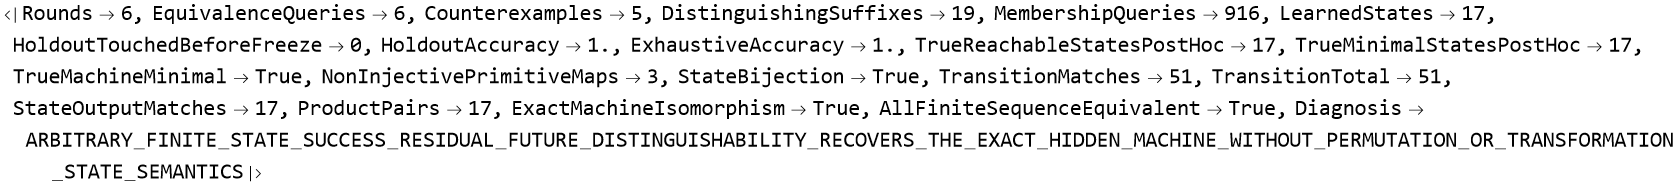

In [49]:
<|

  "Rounds" ->
    learningRoundS116A,

  "EquivalenceQueries" ->
    equivalenceQueryCountS116A,

  "Counterexamples" ->
    Length[
      counterexampleLogS116A
    ],

  "DistinguishingSuffixes" ->
    Length[
      suffixSetS116A
    ],

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS116A,

  "LearnedStates" ->
    learnedStateCountS116A,

  "HoldoutTouchedBeforeFreeze" ->
    holdoutTouchedBeforeFreezeS116A,

  "HoldoutAccuracy" ->
    holdoutAccuracyS116A,

  "ExhaustiveAccuracy" ->
    auditAccuracyS116A,

  "TrueReachableStatesPostHoc" ->
    trueReachableCountS116A,

  "TrueMinimalStatesPostHoc" ->
    trueMinimalStateCountS116A,

  "TrueMachineMinimal" ->
    trueMachineMinimalS116A,

  "NonInjectivePrimitiveMaps" ->
    nonInjectivePrimitiveCountS116A,

  "StateBijection" ->
    stateBijectionPassedS116A,

  "TransitionMatches" ->
    transitionMatchesS116A,

  "TransitionTotal" ->
    transitionTotalS116A,

  "StateOutputMatches" ->
    stateOutputMatchesS116A,

  "ProductPairs" ->
    productPairCountS116A,

  "ExactMachineIsomorphism" ->
    exactMachineIsomorphismS116A,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS116A,

  "Diagnosis" ->
    diagnosisS116A

|>

<|Rounds -> 6, EquivalenceQueries -> 6, Counterexamples -> 5, 
 
>   DistinguishingSuffixes -> 19, MembershipQueries -> 916, LearnedStates -> 17, 
 
>   HoldoutTouchedBeforeFreeze -> 0, HoldoutAccuracy -> 1., ExhaustiveAccuracy -> 1., 
 
>   TrueReachableStatesPostHoc -> 17, TrueMinimalStatesPostHoc -> 17, 
 
>   TrueMachineMinimal -> True, NonInjectivePrimitiveMaps -> 3, StateBijection -> True, 
 
>   TransitionMatches -> 51, TransitionTotal -> 51, StateOutputMatches -> 17, 
 
>   ProductPairs -> 17, ExactMachineIsomorphism -> True, 
 
>   AllFiniteSequenceEquivalent -> True, 
 
>   Diagnosis -> ARBITRARY_FINITE_STATE_SUCCESS_RESIDUAL_FUTURE_DISTINGUISHABILITY_RECOV\
 
>     ERS_THE_EXACT_HIDDEN_MACHINE_WITHOUT_PERMUTATION_OR_TRANSFORMATION_STATE_SEMANTICS\
 
>    |>
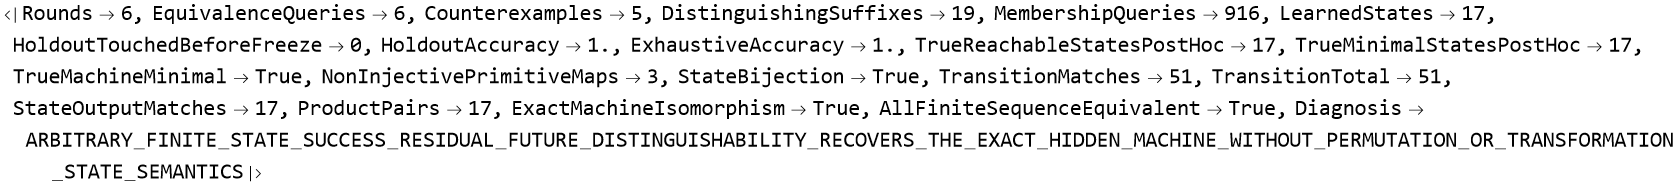

In [54]:
<|

  "Rounds" ->
    learningRoundS116A,

  "EquivalenceQueries" ->
    equivalenceQueryCountS116A,

  "Counterexamples" ->
    Length[
      counterexampleLogS116A
    ],

  "DistinguishingSuffixes" ->
    Length[
      suffixSetS116A
    ],

  "MembershipQueries" ->
    membershipQueriesBeforeFreezeS116A,

  "LearnedStates" ->
    learnedStateCountS116A,

  "HoldoutTouchedBeforeFreeze" ->
    holdoutTouchedBeforeFreezeS116A,

  "HoldoutAccuracy" ->
    holdoutAccuracyS116A,

  "ExhaustiveAccuracy" ->
    auditAccuracyS116A,

  "TrueReachableStatesPostHoc" ->
    trueReachableCountS116A,

  "TrueMinimalStatesPostHoc" ->
    trueMinimalStateCountS116A,

  "TrueMachineMinimal" ->
    trueMachineMinimalS116A,

  "NonInjectivePrimitiveMaps" ->
    nonInjectivePrimitiveCountS116A,

  "StateBijection" ->
    stateBijectionPassedS116A,

  "TransitionMatches" ->
    transitionMatchesS116A,

  "TransitionTotal" ->
    transitionTotalS116A,

  "StateOutputMatches" ->
    stateOutputMatchesS116A,

  "ProductPairs" ->
    productPairCountS116A,

  "ExactMachineIsomorphism" ->
    exactMachineIsomorphismS116A,

  "AllFiniteSequenceEquivalent" ->
    allFiniteSequenceEquivalentS116A,

  "Diagnosis" ->
    diagnosisS116A

|>

Dataset[{<|Round -> 1, CandidateStates -> 2, PrefixCount -> 2, SuffixCount -> 1, 
 
>     UniqueMembershipQueries -> 7, Counterexample -> {1, 0}, CounterexampleLength -> 2|>
 
>     , <|Round -> 2, CandidateStates -> 5, PrefixCount -> 6, SuffixCount -> 3, 
 
>     UniqueMembershipQueries -> 45, Counterexample -> {0, 2, 1}, 
 
>     CounterexampleLength -> 3|>, <|Round -> 3, CandidateStates -> 9, 
 
>     PrefixCount -> 10, SuffixCount -> 6, UniqueMembershipQueries -> 136, 
 
>     Counterexample -> {0, 2, 1, 2}, CounterexampleLength -> 4|>, 
 
>    <|Round -> 4, CandidateStates -> 15, PrefixCount -> 16, SuffixCount -> 10, 
 
>     UniqueMembershipQueries -> 346, Counterexample -> {0, 0, 1, 0, 1}, 
 
>     CounterexampleLength -> 5|>, <|Round -> 5, CandidateStates -> 16, 
 
>     PrefixCount -> 19, SuffixCount -> 14, UniqueMembershipQueries -> 565, 
 
>     Counterexample -> {0, 0, 2, 1, 0, 0}, CounterexampleLength -> 6|>, 
 
>    <|Round -> 6, CandidateStates -> 17, PrefixCount -> 23, SuffixCount -> 19, 
 
>     UniqueMembershipQueries -> 916, Counterexample -> Equivalent, 
 
>     CounterexampleLength -> Missing[Equivalent]|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Round, CandidateStates, PrefixCount, 
 
>      SuffixCount, UniqueMembershipQueries, Counterexample, CounterexampleLength}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`AnyType, 
 
>      TypeSystem`Atom[Integer]}], 6], <||>]
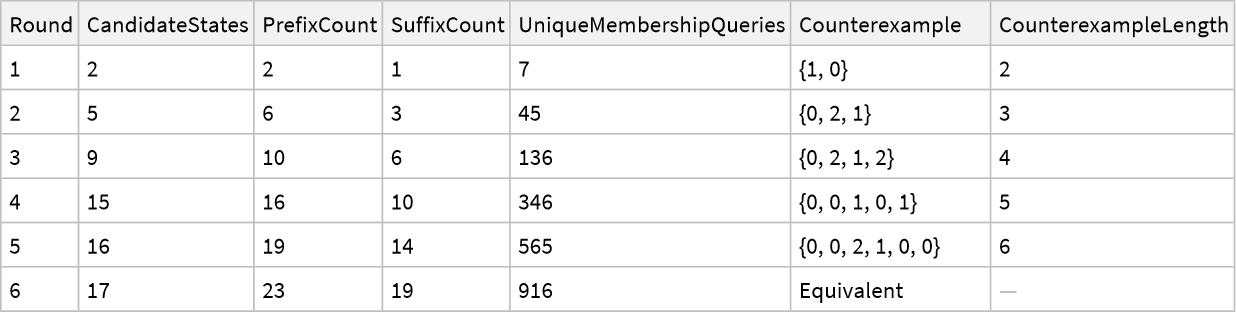

In [59]:
Dataset[
  learningRoundLogS116A
]

In [64]:
Dataset[
  holdoutPerDepthS116A
]

Dataset[{<|Depth -> 20, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 50, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 100, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>, 
 
>    <|Depth -> 200, Sequences -> 100, Matches -> 100, Accuracy -> 1.|>}, 
 
>   TypeSystem`Vector[TypeSystem`Struct[{Depth, Sequences, Matches, Accuracy}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[Real]}], 4], <||>]

Dataset[{<|Token -> 0, SourceStates -> 17, UniqueDestinations -> 13, 
 
>     Injective -> False|>, <|Token -> 1, SourceStates -> 17, UniqueDestinations -> 12, 
 
>     Injective -> False|>, <|Token -> 2, SourceStates -> 17, UniqueDestinations -> 11, 
 
>     Injective -> False|>}, TypeSystem`Vector[TypeSystem`Struct[{Token, SourceStates, 
 
>      UniqueDestinations, Injective}, 
 
>     {TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], TypeSystem`Atom[Integer], 
 
>      TypeSystem`Atom[TypeSystem`Boolean]}], 3], <||>]
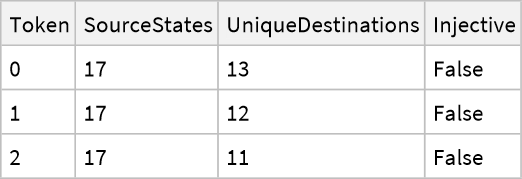

In [69]:
Dataset[
  truePrimitiveInjectivityS116A
]